<a href="https://colab.research.google.com/github/yeavil-neny/NLP-ProcesamientoLeguajeNatural/blob/main/Taller_1/proyecto_fundamentos_NLP_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desarrollo del taller 1**.

### **Definición del Problema y Carga de Datos**

En este proyecto abordaremos la **clasificación de la satisfacción de clientes en plataformas de e-commerce** mediante técnicas de Procesamiento de Lenguaje Natural (NLP).

Las plataformas reciben miles de reseñas que, por su volumen, son difíciles de analizar manualmente. Por ello, se propone desarrollar un sistema que interprete automáticamente el sentimiento de cada reseña y lo clasifique en una escala de **1 a 5 estrellas**.

Para lograrlo, utilizaremos un modelo basado en redes LSTM, combinado con Embeddings, que permita capturar el contexto y la secuencia de las palabras.

Los datos provendrán del dataset **amazon_reviews_multi en español de Hugging Face**, compuesto por reseñas reales de compradores. Esto permitirá trabajar con desafíos propios del lenguaje natural, como errores ortográficos, expresiones informales y textos de diferentes longitudes.


In [23]:
from datasets import load_dataset
import torch

# Verificamos GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Cargamos el dataset (Amazon Reviews en español por SetFit)
print("Descargando el dataset 'SetFit/amazon_reviews_multi_es'...")
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

# Tomamos el subconjunto para entrenar rápido (¡mezclando los datos primero!)
subset_size_train = 50000
subset_size_eval = 5000

# Añadimos .shuffle(seed=42) antes de hacer el .select()
train_data = dataset['train'].shuffle(seed=42).select(range(subset_size_train))
val_data = dataset['validation'].shuffle(seed=42).select(range(subset_size_eval))
test_data = dataset['test'].shuffle(seed=42).select(range(subset_size_eval))

# Resumen y ejemplo
print(f"\n--- Resumen de Datos ---")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print("\n--- Ejemplo de un registro ---")
print(f"Texto: {train_data[0]['text'][:250]}...")
print(f"Etiqueta (Estrellas): {train_data[0]['label']} (Escala de 0 a 4, donde 0 es 1 estrella)")

Descargando el dataset 'SetFit/amazon_reviews_multi_es'...


Repo card metadata block was not found. Setting CardData to empty.



--- Resumen de Datos ---
Train: 50000 | Val: 5000 | Test: 5000

--- Ejemplo de un registro ---
Texto: La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente....
Etiqueta (Estrellas): 2 (Escala de 0 a 4, donde 0 es 1 estrella)


In [24]:
train_data


Dataset({
    features: ['id', 'text', 'label', 'label_text'],
    num_rows: 50000
})

In [25]:
val_data

Dataset({
    features: ['id', 'text', 'label', 'label_text'],
    num_rows: 5000
})

In [26]:
test_data

Dataset({
    features: ['id', 'text', 'label', 'label_text'],
    num_rows: 5000
})

### **Análisis Exploratorio de Datos (EDA)**

In [27]:
import pandas as pd

# Convertimos el dataset de Hugging Face a un DataFrame de Pandas
df_train = train_data.to_pandas()

# Mostramos las primeras 20 filas para explorar su estructura
df_train.tail(20)

,id,text,label,label_text
49980,es_0197991,"No lo he usado, se ve algo endeble pero lo que...",0,0
49981,es_0119839,POR EL PRECIO DE ESTOS DOS CATUCHOS ES IMPRESI...,3,3
49982,es_0318519,Regular estos dispositivos pecan de lo mismo.r...,2,2
49983,es_0236117,"Está bien, tampoco para tirar cohetes porque s...",2,2
49984,es_0984004,El kit está bien pero el pegamento es malísimo...,2,2
49985,es_0282933,Cuando llego nos parecio genial...muy comoda y...,0,0
49986,es_0496275,Hola yo la compré hace tiempo y me va muy bien...,2,2
49987,es_0303969,Satisfechos con el producto pero no con la ent...,4,4
49988,es_0413793,¿Alguien sabe donde se puede descargar las act...,2,2
49989,es_0267428,Todo ok y muy comoda,3,3


Al analizar las reseñas, se identifican algunas inconsistencias entre el contenido expresado por los usuarios y la calificación asignada. Por ejemplo, existen reseñas con una calificación de 3 cuyo contenido refleja un nivel de satisfacción que podría corresponder a la categoría 4. Del mismo modo, algunos usuarios manifiestan que su experiencia fue excelente, pero seleccionan una categoría inmediatamente inferior a la máxima.

Estas discrepancias pueden introducir ruido en las etiquetas utilizadas para entrenar el modelo y dificultar la diferenciación entre clases cercanas. En consecuencia, el modelo podría presentar mayor confusión al clasificar reseñas pertenecientes a categorías adyacentes, como 3 y 4.

A partir de este comportamiento, se espera que las clases extremas (0 y 4) presenten una mayor precisión en las predicciones del modelo LSTM, debido a que, en principio, deberían representar sentimientos más claramente diferenciados. Por el contrario, las clases intermedias podrían presentar un mayor nivel de confusión como consecuencia de la subjetividad de las calificaciones y de las inconsistencias observadas entre el texto de las reseñas y las etiquetas asignadas.

/tmp/ipykernel_978/727094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='label', palette='viridis')


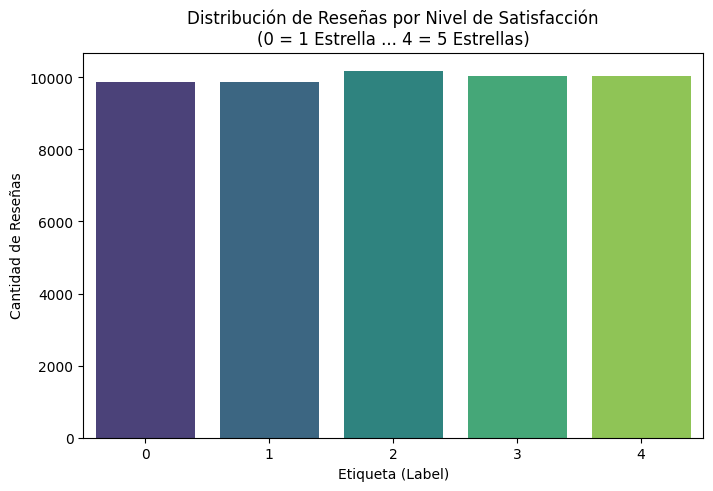

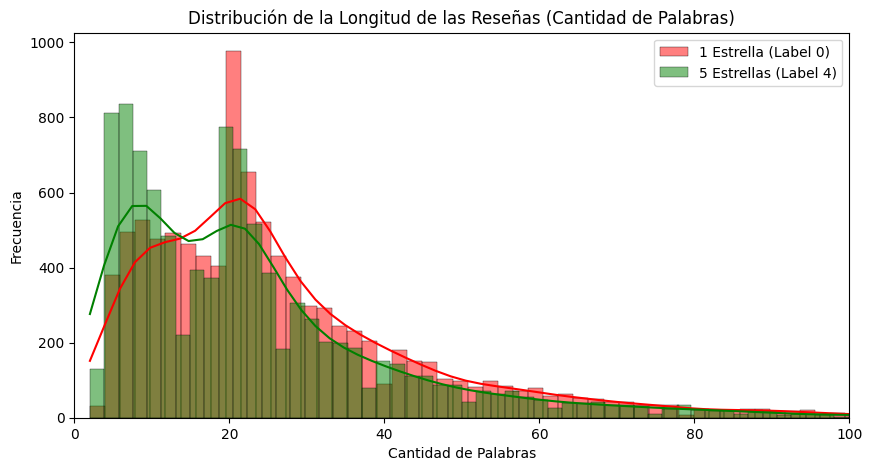

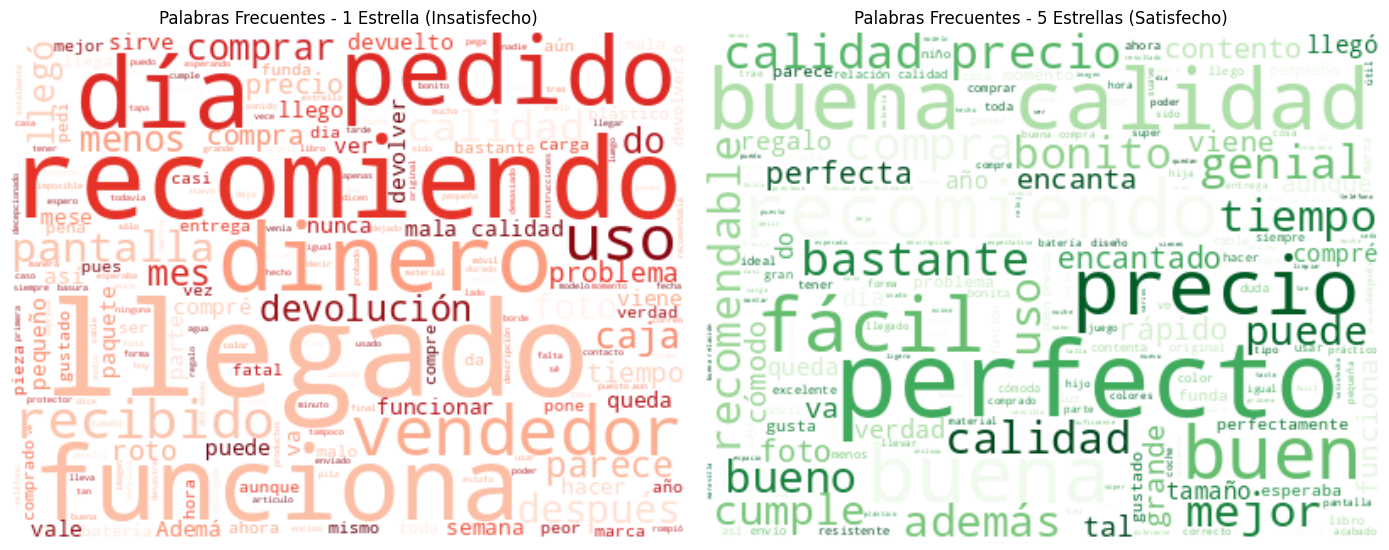

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Descargamos las palabras vacías (stopwords) en español para limpiar las nubes de palabras
nltk.download('stopwords', quiet=True)
stop_words_sp = set(stopwords.words('spanish'))
# Añadimos algunas palabras comunes que no aportan sentimiento
stop_words_sp.update(['producto', 'amazon', 'bien', 'mal', 'hace', 'solo', 'si', 'mas', 'q', 'que'])

# 1. Convertimos el dataset de Hugging Face a un DataFrame de Pandas
df_train = train_data.to_pandas()

# Calculamos la longitud de cada reseña (cantidad de palabras)
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

# --- GRÁFICO 1: Distribución de Clases ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='label', palette='viridis')
plt.title('Distribución de Reseñas por Nivel de Satisfacción\n(0 = 1 Estrella ... 4 = 5 Estrellas)')
plt.xlabel('Etiqueta (Label)')
plt.ylabel('Cantidad de Reseñas')
plt.show()

# --- GRÁFICO 2: Longitud de Textos (Extremos) ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df_train[df_train['label'] == 0], x='word_count', color='red', label='1 Estrella (Label 0)', kde=True, alpha=0.5)
sns.histplot(data=df_train[df_train['label'] == 4], x='word_count', color='green', label='5 Estrellas (Label 4)', kde=True, alpha=0.5)
plt.title('Distribución de la Longitud de las Reseñas (Cantidad de Palabras)')
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia')
plt.legend()
plt.xlim(0, 100) # Limitamos a 100 palabras para enfocar el cuerpo principal
plt.show()

# --- GRÁFICO 3: Nubes de Palabras ---
text_negativo = " ".join(df_train[df_train['label'] == 0]['text'].tolist())
text_positivo = " ".join(df_train[df_train['label'] == 4]['text'].tolist())

# Generamos las nubes
wc_neg = WordCloud(stopwords=stop_words_sp, background_color='white', colormap='Reds', width=400, height=300).generate(text_negativo)
wc_pos = WordCloud(stopwords=stop_words_sp, background_color='white', colormap='Greens', width=400, height=300).generate(text_positivo)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Palabras Frecuentes - 1 Estrella (Insatisfecho)')
axes[0].axis('off')

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Palabras Frecuentes - 5 Estrellas (Satisfecho)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

La grafica de barras muestran que hay una cantidad muy similar de reseñas para 1, 2, 3, 4 y 5 estrellas (rondando las 10000 reseñas por clase). Lo que indica que las clases se encuentran balanceadas reduciendo el riego de sesgo durante el entrenamiento de los modelos.

La grafica de frecuencia nos muestra que fijar una longitud máxima de secuencia (max_length) alrededor de 50 a 100 tokens será más que suficiente para capturar el mensaje completo del cliente sin desperdiciar memoria computacional.

Existe una separación semántica evidente entre los dos extremos de satisfacción. En la nube de 1 estrella, predominan palabras de fallo, frustración o tiempo (ej. roto, devolver, dinero, llegó, malo, nunca). En la nube de 5 estrellas, destacan palabras de exaltación y valor (ej. perfecto, calidad, precio, recomiendo, encanta, excelente).

In [29]:
# Iteramos por cada una de las 5 categorías (de 0 a 4)
for estrella in range(5):
    print(f"{"="*50}")
    print(f"CATEGORÍA {estrella} ({estrella + 1} Estrellas)")
    print(f"{"="*50}")

    # Filtramos el DataFrame por la etiqueta actual y tomamos los primeros 2 registros
    ejemplos = df_train[df_train['label'] == estrella].head(2)

    for idx, row in ejemplos.iterrows():
        print(f" {row['text']}\n")

CATEGORÍA 0 (1 Estrellas)
 Tiene 6 meses y ya se ha roto una goma

 35 eur tirados a la basura, no me ha servido, me quedé sin batería y no me la cargó

CATEGORÍA 1 (2 Estrellas)
 El servicio ha sido muy bueno, me ha llegado 2 días antes de lo previsto. En cuanto al producto no es que me haya dado muy buenas primeras impresiones. El borde del protector es de plástico y lo único que hay de cristal es la pantalla. Además el plástico es muy fino. A nivel estético queda muy bien y se ajusta perfectamente, la única queja que tengo es eso, que no sea todo de cristal y que para mi gusto es demasiado fino. De la resistencia no tengo ni idea ya que es el primer día que lo llevo. No creo que sea mal producto del todo si no que depende del gusto y el cuidado que tenga cada uno de su móvil. Personalmente creo que por el mismo precio hay otros productos que si que son enteros de cristal y más gordos que por lo menos a mí me generan más confianza.

 Queda muy feo con el borde metalico ademas tapa la

Al analizar los textos, se observa que los extremos de satisfacción utilizan un lenguaje directo que facilitará el aprendizaje del modelo. Las reseñas de una estrella se centran en quejas puntuales sobre pérdida de dinero o fallas físicas del producto, mientras que las de cinco estrellas validan la compra con adjetivos positivos directos ("genial", "perfecto"). Esta separación semántica permitirá que los embeddings clasifiquen los casos positivos y negativos con menor margen de error.

Por otro lado, el principal reto para la red neuronal se encuentra en las categorías intermedias, donde el lenguaje es mixto y con múltiples matices. En estos niveles, los usuarios emplean conectores como "pero" o "aunque" para contrastar aspectos positivos del servicio con detalles negativos del producto en una misma oración. En estos casos de satisfacción parcial, la arquitectura LSTM resulta clave: en lugar de contar palabras aisladas, procesará el contexto secuencial completo de la frase para asignar la clasificación correcta.

### **Preprocesamiento, Tokenización y DataLoaders**

Las redes neuronales no entienden texto en bruto. En esta fase transformaremos nuestras reseñas en tensores numéricos consumibles por PyTorch. El proceso consta de:
1. **Tokenización:** Limpiar el texto y dividirlo en palabras.
2. **Vocabulario:** Crear un diccionario que asigne un ID numérico único a las 20,000 palabras más frecuentes.
3. **Padding:** Estandarizar la longitud de todas las oraciones a 100 tokens (como vimos en el EDA, la mayoría de reseñas son cortas).
4. **DataLoaders:** Empaquetar los datos en lotes (*batches*) para inyectarlos a la tarjeta gráfica durante el entrenamiento.

La función simple_tokenizer toma el texto crudo, lo pasa a minúsculas y elimina caracteres raros. Sin embargo, a diferencia de otros modelos, aquí le ordenamos explícitamente que no borre los signos de exclamación (!). En el análisis de sentimiento, un "!" aporta muchísima información emocional, por lo que separar la frase en palabras conservando este símbolo es clave.

El código lee todas las reseñas de entrenamiento y cuenta cuáles son las 20,000 palabras más repetidas. A cada una le asigna un número entero único (su ID). Además, crea dos identificadores especiales:

[PAD] (ID 0): Un espacio en blanco de "relleno".

[UNK] (ID 1): Significa Unknown (Desconocido). Se usará si en el futuro un cliente escribe una palabra rarísima que no está en nuestro top 20,000.

La función tokenize_text toma la frase ya separada y busca cada palabra en el diccionario para convertirla en su número ID.
Como las redes neuronales exigen que todas las entradas tengan exactamente el mismo tamaño, usamos el Padding: si una reseña solo tiene 5 palabras (5 números), el código rellena los 95 espacios restantes con el número 0 ([PAD]) hasta que la lista mida exactamente 100 números.

La memoria de la computadora explotaría si intentamos enseñarle al modelo las 50,000 reseñas de entrenamiento al mismo tiempo.  

La clase AmazonReviewsDataset toma las listas de números y las convierte en Tensores (matrices matemáticas optimizadas de PyTorch).  

El DataLoader toma todos esos tensores y los divide en "Lotes" (batches). Con un tamaño de lote de 32, se crean 1,563 lotes de reseñas en total. El modelo procesará 32 reseñas, ajustará su aprendizaje, y luego tomará las siguientes 32 de forma iterativa.

Repo card metadata block was not found. Setting CardData to empty.


Vocabulario de 5000 palabras -> Cobertura del corpus: 94.21%
Vocabulario de 10000 palabras -> Cobertura del corpus: 97.18%
Vocabulario de 20000 palabras -> Cobertura del corpus: 99.07%
Vocabulario de 30000 palabras -> Cobertura del corpus: 99.79%
Vocabulario de 50000 palabras -> Cobertura del corpus: 100.00%


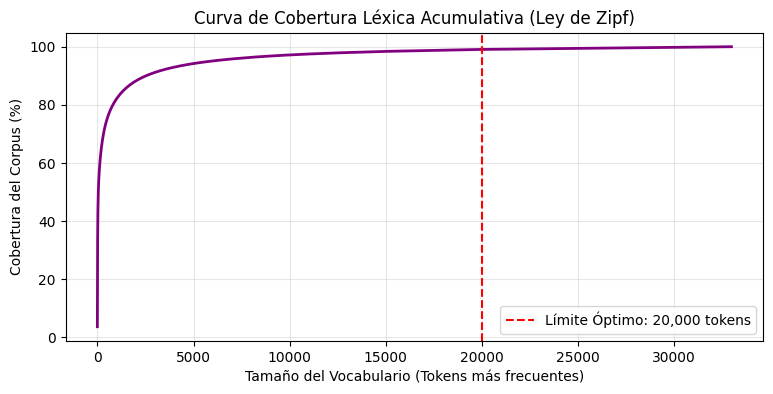

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from datasets import load_dataset

# --- Replicar la preparación de datos necesaria para esta celda ---
# Cargar el dataset
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

# Tomar el subconjunto para entrenar
subset_size_train = 50000
train_data = dataset['train'].shuffle(seed=42).select(range(subset_size_train))

# Definir el tokenizer
def simple_tokenizer(text: str):
    text = text.lower()
    text = re.sub(r'([!¡])', r' \1 ', text)
    text = re.sub(r'[^a-záéíóúüñ0-9!¡]+', ' ', text)
    return text.strip().split()

# Construir el vocabulario y contar tokens
token_counts = Counter()
for text in train_data['text']:
    token_counts.update(simple_tokenizer(text))

max_vocab = 20000
top_tokens = [token for token, _ in token_counts.most_common(max_vocab - 2)]

vocab = {'[PAD]': 0, '[UNK]': 1}
for token in top_tokens:
    vocab[token] = len(vocab)
# --- Fin de la replicación de preparación de datos ---

# Calcular la frecuencia acumulativa del vocabulario
total_tokens_count = sum(token_counts.values())
sorted_frequencies = sorted([freq for token, freq in token_counts.most_common()], reverse=True)
cumulative_frequencies = np.cumsum(sorted_frequencies) / total_tokens_count

# Puntos de corte a evaluar
vocab_sizes = [5000, 10000, 20000, 30000, 50000]
coverages = [cumulative_frequencies[min(v, len(cumulative_frequencies)-1)] * 100 for v in vocab_sizes]

for v, cov in zip(vocab_sizes, coverages):
    print(f"Vocabulario de {v} palabras -> Cobertura del corpus: {cov:.2f}%")

# Gráfica de Cobertura Acumulativa
plt.figure(figsize=(9, 4))
plt.plot(cumulative_frequencies[:40000] * 100, color='purple', lw=2)
plt.axvline(x=20000, color='red', linestyle='--', label='Límite Óptimo: 20,000 tokens')
plt.title('Curva de Cobertura Léxica Acumulativa (Ley de Zipf)')
plt.xlabel('Tamaño del Vocabulario (Tokens más frecuentes)')
plt.ylabel('Cobertura del Corpus (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


La **Curva de Cobertura Léxica Acumulativa** (inspirada en la **Ley de Zipf** sobre la distribución de la frecuencia de las palabras en el lenguaje natural) obtenida en la gráfica anterior, nos permite justificar la elección de un tamaño de vocabulario de 20,000 tokens.

Como se observa en la visualización, un vocabulario de 20,000 palabras es capaz de capturar aproximadamente el **99.07% de la cobertura del corpus** de reseñas. Este punto representa un equilibrio óptimo: al incluir más palabras (por ejemplo, 30,000 o 50,000), la ganancia en cobertura léxica es marginal (99.79% y 100% respectivamente), mientras que el costo computacional y la complejidad del modelo aumentarían significativamente al procesar y almacenar un vocabulario más grande con muchas palabras de baja frecuencia y poco valor informativo. Por otro lado, un vocabulario más pequeño (5,000 o 10,000 palabras) dejaría una porción considerable del corpus como '[UNK]' (desconocida), perdiendo valiosa información semántica.

Esta decisión se alinea con los principios de la Ley de Zipf, que postula que unas pocas palabras son muy frecuentes, mientras que la mayoría son raras. Al truncar el vocabulario en 20,000 palabras, nos aseguramos de incluir las palabras más informativas y frecuentes, dejando fuera las 'colas largas' de palabras poco comunes que rara vez aparecen, pero que dispararían el tamaño del vocabulario.

Para profundizar en la Ley de Zipf y su aplicación, se puede consultar el artículo: "Ley de frecuencia de palabras de Zipf en el lenguaje natural: una revisión crítica y perspectivas futuras.": https://pmc.ncbi.nlm.nih.gov/articles/PMC4176592/


In [31]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re

def simple_tokenizer(text: str):
    text = text.lower()
    # Separamos los signos de exclamación dejándoles un espacio a los lados para que no se peguen a las palabras
    text = re.sub(r'([!¡])', r' \1 ', text)
    # Luego limpiamos lo demás
    text = re.sub(r'[^a-záéíóúüñ0-9!¡]+', ' ', text)
    return text.strip().split()

# 2. Construir el vocabulario basado SOLO en el conjunto de entrenamiento
print("Construyendo vocabulario...")
token_counts = Counter()
for text in train_data['text']:
    token_counts.update(simple_tokenizer(text))

max_vocab = 20000
top_tokens = [token for token, _ in token_counts.most_common(max_vocab - 2)]

# Guardamos espacio para los tokens especiales
vocab = {'[PAD]': 0, '[UNK]': 1}
for token in top_tokens:
    vocab[token] = len(vocab)

print(f"Tamaño del vocabulario: {len(vocab)} tokens")

# 3. Función para convertir texto a lista de IDs (con padding)
def tokenize_text(text: str, max_length: int = 100):
    # max_length de 100 es ideal según vimos en nuestra gráfica de longitud
    token_ids = [vocab.get(token, vocab['[UNK]']) for token in simple_tokenizer(text)[:max_length]]
    # Añadimos ceros (Padding) para que todas las secuencias midan exactamente 100
    token_ids += [vocab['[PAD]']] * (max_length - len(token_ids))
    return token_ids

# Prueba rápida para ver qué hace el código
print("\nEjemplo de texto:", "¡Este producto es terrible!")
print("Tokenizado en IDs:", tokenize_text("¡Este producto es terrible!", max_length=15))

# 4. Crear la clase Dataset y los DataLoaders de PyTorch
class AmazonReviewsDataset(Dataset):
    def __init__(self, dataset, tokenizer_fn, max_length=100):
        self.dataset = dataset
        self.tokenizer_fn = tokenizer_fn
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset[idx]
        input_ids = torch.tensor(self.tokenizer_fn(row['text'], self.max_length), dtype=torch.long)
        # Longitud real = cantidad de tokens antes de llegar al padding, con mínimo de 1
        length = int((input_ids != 0).sum().item())
        length = max(length, 1)
        label = torch.tensor(row['label'], dtype=torch.long)
        return {'input_ids': input_ids, 'length': length, 'label': label}

# Define el campo de visión fijo del modelo para cada reseña.
seq_length = 100
batch_size = 32 if torch.cuda.is_available() else 16

print("\nEmpaquetando en DataLoaders...")
train_dataset_pt = AmazonReviewsDataset(train_data, tokenize_text, seq_length)
val_dataset_pt = AmazonReviewsDataset(val_data, tokenize_text, seq_length)
test_dataset_pt = AmazonReviewsDataset(test_data, tokenize_text, seq_length)

train_loader = DataLoader(train_dataset_pt, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_pt, batch_size=batch_size)
test_loader = DataLoader(test_dataset_pt, batch_size=batch_size)

print(f"¡DataLoaders listos! Lotes de entrenamiento creados: {len(train_loader)}")

Construyendo vocabulario...
Tamaño del vocabulario: 20000 tokens

Ejemplo de texto: ¡Este producto es terrible!
Tokenizado en IDs: [911, 52, 32, 8, 3699, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Empaquetando en DataLoaders...
¡DataLoaders listos! Lotes de entrenamiento creados: 1563


Se identifico un problema con el padding, este radica en que las reseñas cortas se rellenan con ceros ([PAD]) para alcanzar la longitud fija de 100 tokens, lo que podría provocar que la red neuronal malgaste capacidad computacional procesando espacios vacíos sin contenido semántico. Este inconveniente se resolvió en el cuaderno aplicando dos estrategias clave: la configuración de padding_idx=0 en la capa de embeddings para que PyTorch ignore y desactive la actualización de gradientes en dichos ceros, y el uso de la función pack_padded_sequence en el bloque LSTM, la cual le indica estrictamente a la red dónde finaliza cada reseña real para suspender de forma matemática las operaciones recurrentes sobre el relleno.

Cuando se utiliza padding sin excluir formalmente los ceros, el modelo comete el error de procesar los espacios vacíos como si tuvieran un significado real. Esto distorsiona las activaciones internas de la celda recurrente, provocando que la red se sature de información irrelevante y no logre identificar los patrones que diferencian las categorías de satisfacción.


### **Definición de la Arquitectura del Modelo (Embeddings y LSTM)**

Para resolver nuestro problema de clasificación de texto, construiremos una arquitectura neuronal en PyTorch estructurada en tres componentes principales:

1. **Capa de Embeddings:** Es el puente que transforma los IDs numéricos enteros generados en la tokenización en vectores densos continuos. Aquí es donde el modelo aprende a representar las palabras y sus relaciones semánticas en el espacio vectorial.
2. **Bloque Recurrente (LSTM):** Capa encargada de procesar la secuencia de palabras de la reseña paso a paso. A diferencia de las redes tradicionales, la LSTM posee "puertas" internas que le permiten recordar información importante a lo largo de oraciones largas (ideal para entender el contexto global de una queja o elogio). Añadiremos un parámetro de dropout interno para evitar el sobreajuste.
3. **Capa Lineal de Clasificación:** Toma la representación final que entrega la LSTM y la proyecta en 5 neuronas de salida, correspondientes a nuestras categorías de satisfacción (de 0 a 4 estrellas).

**Definición del modelo LSTM**

En nuestro código configuramos 1 capa LSTM (num_layers=1 por defecto en PyTorch cuando no se especifica otro número).

128 dimensiones (hidden_dim = 128): Cada celda interna de la LSTM procesa la palabra actual combinándola con una memoria interna representada por un vector de 128 números. Es la "capacidad de retención" de contexto que tiene el modelo mientras lee la reseña.

El Campo de Visión / Longitud de Secuencia (seq_length o max_length)
Tamaño: 100 tokens (palabras/símbolos).

Qué significa: Este es el "campo de visión" estricto del modelo por cada reseña. Como vimos en la gráfica del EDA, la gran mayoría de las reseñas de Amazon caben perfectamente en este rango. Si una reseña es más larga, el tokenizador la corta a los 100 tokens; si es más corta, se rellena con ceros ([PAD]). Por lo tanto, el modelo siempre "ve" un ancho fijo de 100 pasos por cada lote.

Tamaño: 128 dimensiones (embedding_dim = 128): Cada una de las 20 mil
 palabras de nuestro vocabulario se transforma en un vector denso de 128 números reales que mapean su significado semántico antes de entrar a la LSTM.






**Documentación de Hiperparámetros de la Red LSTM**


Para configurar el entrenamiento y la capacidad de representación de nuestro modelo, hemos definido los siguientes hiperparámetros clave:

* **Capas Ocultas (`num_layers = 1`):** Se implementó una capa recurrente única, suficiente para capturar las dependencias temporales y secuenciales básicas de las reseñas sin caer en sobreajuste prematuro en esta fase experimental.
* **Dimensión del Estado Oculto (`hidden_dim = 128`):** Cada celda de la LSTM mantiene una memoria interna de 128 dimensiones, otorgándole la capacidad de retener y combinar el contexto de las palabras a lo largo de toda la secuencia.
* **Campo de Visión / Longitud de Secuencia (`max_length = 100`):** Basado en el Análisis Exploratorio de Datos (EDA), se fijó el tamaño de entrada a 100 tokens por reseña. Las reseñas más largas se truncan y las más cortas se rellenan con ceros (`[PAD]`), estandarizando el tamaño de los lotes (*batches*).
* **Dimensión de los Embeddings (`embedding_dim = 128`):** Cada uno de los 8,377 tokens del vocabulario se mapea a un espacio vectorial denso de 128 dimensiones, permitiendo que la red aprenda relaciones semánticas entre las palabras.
* **Regularización (`Dropout = 0.3`):** Se configuró una tasa de abandono de 0.3 tanto internamente en la LSTM como en la capa previa al clasificador lineal, con el fin de apagar neuronas aleatoriamente y forzar al modelo a generalizar mejor.

In [33]:
import torch.nn as nn

class AdvancedLSTMClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_classes: int, embedding_dim: int = 128, hidden_dim: int = 128, dropout: float = 0.3):
        super().__init__()

        # 1. Capa de Embeddings (Mapea cada token a un vector de embedding_dim)
        # padding_idx=0 le avisa al modelo que ignore los ceros del padding para no sesgar el aprendizaje.
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # 2. Capa LSTM con soporte para Dropout (mejora la generalización)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            dropout=dropout if dropout > 0 else 0.0
        )

        # 3. Capa de Regularización (Dropout para apagar neuronas aleatoriamente y evitar memorización)
        self.dropout = nn.Dropout(dropout)

        # 4. Capa Lineal Final (Convierte el estado oculto de la LSTM en las 5 clases de estrellas)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)

        # Empaquetamos la secuencia para que la LSTM ignore el padding
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden_state, _) = self.lstm(packed)

        out = self.dropout(hidden_state[-1])
        logits = self.classifier(out)
        return logits

# Instanciamos el modelo con los parámetros adecuados para nuestro dataset de Amazon
vocab_size = len(vocab)
num_classes = 5  # De 0 a 4 estrellas
embedding_dim = 128
hidden_dim = 128

model = AdvancedLSTMClassifier(
    vocab_size=vocab_size,
    num_classes=num_classes,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    dropout=0.3
).to(device)

# Imprimimos la arquitectura para verificarla
print("--- Arquitectura del Modelo Creada ---")
print(model)

--- Arquitectura del Modelo Creada ---
AdvancedLSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=5, bias=True)
)


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


### **Entrenamiento, Evaluación y Resultados.**

## Ciclo de Entrenamiento, Evaluación y Métricas

En esta última fase, pondremos a prueba nuestro modelo `AdvancedLSTMClassifier` utilizando los DataLoaders que preparamos:
1. **Función de Pérdida (`CrossEntropyLoss`) y Optimizador (`Adam`):** Configuraremos la tasa de aprendizaje (*learning rate*) a `1e-3` para actualizar los pesos de la red.
2. **Ciclo de Entrenamiento y Validación:** Entrenaremos durante 2 o 3 épocas (*epochs*), calculando el error y la precisión en cada ciclo tanto para el conjunto de entrenamiento como para validación.
3. **Métrica Final en Test:** Evaluaremos el modelo en datos totalmente nuevos (*test_loader*) para medir su desempeño real en producción.

In [ ]:
from tqdm.auto import tqdm

# 1. Definimos la función de pérdida y el optimizador Adam
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Definimos las épocas
epochs = 2 if torch.cuda.is_available() else 1

def run_epoch(dataloader, training: bool = True):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    # Barra de progreso limpia para el entrenamiento
    for batch in tqdm(dataloader, disable=not training):
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        # CORRECCIÓN 1: Extraemos las longitudes del batch
        lengths = batch['length']

        # CORRECCIÓN 2: Le pasamos tanto los input_ids como las lengths al modelo
        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)

        if training:
            # Backpropagation y optimización
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

# 2. Bucle principal de entrenamiento
history = []
print("--- Iniciando Entrenamiento del Modelo LSTM ---")
for epoch in range(epochs):
    train_loss, train_acc = run_epoch(train_loader, training=True)

    with torch.no_grad():
        val_loss, val_acc = run_epoch(val_loader, training=False)

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc
    })
    print(f"Epoch {epoch + 1}: train_loss={train_loss:.4f} | train_acc={train_acc:.4f} || val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

# 3. Mostramos historial en una tabla limpia de Pandas
import pandas as pd
history_df = pd.DataFrame(history)
print("\n--- Resumen Histórico de Entrenamiento ---")
display(history_df)

# 4. Evaluación final en el conjunto de prueba (Test)
with torch.no_grad():
    test_loss, test_acc = run_epoch(test_loader, training=False)

print(f"\n Resultados Finales en Test:")
print(f"Test Loss (Pérdida): {test_loss:.4f}")
print(f"Test Accuracy (Precisión): {test_acc:.4f} ({test_acc * 100:.2f}%)")

--- Iniciando Entrenamiento del Modelo LSTM ---


  0%|          | 0/1563 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import torch

# 1. Asegurar que el modelo está en modo evaluación y en el dispositivo correcto
model.eval()
model = model.to(device)

all_preds = []
all_labels = []

# 2. Recorrer todo el test_loader para recolectar predicciones y etiquetas reales
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        lengths = batch['length']

        # Ejecutar modelo
        logits = model(input_ids, lengths)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Definir las etiquetas de las clases (Escala de 0 a 4 estrellas)
class_names = [
    "1 Estrella (Clase 0)",
    "2 Estrellas (Clase 1)",
    "3 Estrellas (Clase 2)",
    "4 Estrellas (Clase 3)",
    "5 Estrellas (Clase 4)"
]

# 4. Generar e imprimir el reporte detallado de clasificación
print("--- Reporte Detallado de Métricas por Clase (Modelo Celda 15) ---")
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de confusión usando scikit-learn
cm = confusion_matrix(all_labels, all_preds)

# 2. Definir las etiquetas de las clases
class_names = [
    "1 Estrella (0)",
    "2 Estrellas (1)",
    "3 Estrellas (2)",
    "4 Estrellas (3)",
    "5 Estrellas (4)"
]

# 3. Graficar usando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - AdvancedLSTMClassifier (Celda 15)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real (Estrellas)')
plt.tight_layout()
plt.show()

**Entrenamos 2 épocas más para ver cómo mejora la precisión**

In [ ]:
# Entrenamos 2 épocas más para ver cómo mejora la precisión
additional_epochs = 3
print("--- Continuando el Entrenamiento del Modelo LSTM ---")

for epoch in range(additional_epochs):
    current_epoch = len(history) + 1
    train_loss, train_acc = run_epoch(train_loader, training=True)

    with torch.no_grad():
        val_loss, val_acc = run_epoch(val_loader, training=False)

    history.append({
        'epoch': current_epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc
    })
    print(f"Epoch {current_epoch}: train_loss={train_loss:.4f} | train_acc={train_acc:.4f} || val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

# Actualizamos la tabla histórica completa
history_df = pd.DataFrame(history)
print("\n--- Historial Completo Actualizado ---")
display(history_df)

# Evaluación final actualizada en Test
with torch.no_grad():
    test_loss, test_acc = run_epoch(test_loader, training=False)

print(f"\n Resultados Finales Actualizados en Test:")
print(f"Test Loss (Pérdida): {test_loss:.4f}")
print(f"Test Accuracy (Precisión): {test_acc:.4f} ({test_acc * 100:.2f}%)")

In [ ]:
!pip install --upgrade transformers huggingface_hub lightning datasets torchmetrics -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy

# 1. Bloque LSTM ÓPTIMO (Usando lengths y pack_padded_sequence)
class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        # Empaquetamos la secuencia para ignorar matemáticamente el padding
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        # Retornamos el último estado oculto
        return hidden[-1]

# 2. Módulo de PyTorch Lightning (Totalmente sincronizado con lengths)
class AmazonReviewClassifierWithLSTM(pl.LightningModule):
    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int = 256, hidden_dim: int = 256):
        super().__init__()
        self.num_classes = num_classes
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3)

        # Reemplaza todo el nn.Sequential por algo muy simple:
        self.classifier = nn.Sequential(
            nn.Dropout(0.4), # Un poco más de dropout
            nn.Linear(hidden_dim, num_classes) # Directo a las 5 clases
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x, lengths):
        embeddings = self.lstm(x, lengths)
        return self.classifier(embeddings)

    def training_step(self, batch, batch_idx):
        x, lengths, y = batch['input_ids'], batch['length'], batch['label']
        y_hat = self(x, lengths)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, lengths, y = batch['input_ids'], batch['length'], batch['label']
        y_hat = self(x, lengths)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, lengths, y = batch['input_ids'], batch['length'], batch['label']
        y_hat = self(x, lengths)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-4)

# 3. Inicialización y Ejecución
model_pl = AmazonReviewClassifierWithLSTM(
    vocab_size=len(vocab) + 1,
    num_classes=5,
    emb_dim=64,
    hidden_dim=64
)

tb_logger = TensorBoardLogger('tb_logs', name='AmazonLSTMClassifier')
callbacks = [EarlyStopping(monitor='val-loss', patience=3, mode='min')]

trainer = pl.Trainer(
    max_epochs=10,
    devices=1 if torch.cuda.is_available() else 0,
    logger=tb_logger,
    callbacks=callbacks,
    precision="16-mixed" if torch.cuda.is_available() else 32
)

print("--- Iniciando Entrenamiento Corregido (Con Lengths en Todo) ---")
trainer.fit(model_pl, train_dataloaders=train_loader, val_dataloaders=val_loader)

print("\n--- Ejecutando Evaluación Final en Test ---")
trainer.test(model_pl, dataloaders=test_loader)

In [ ]:
import pandas as pd
import torch

# 1. Ponemos el modelo en modo evaluación (apaga el Dropout)
model_pl.eval()
model_pl = model_pl.to(device) # Aseguramos que esté en la GPU si está disponible

# Listas para guardar los datos
textos = []
reales = []
predicciones = []

# 2. Tomamos los primeros 15 o 20 ejemplos de nuestro set de pruebas
num_ejemplos = 15

print(f"Generando predicciones para {num_ejemplos} reseñas...\n")

with torch.no_grad():
    for i in range(num_ejemplos):
        # Extraemos el texto original y la etiqueta de HuggingFace
        texto = test_data[i]['text']
        etiqueta_real = test_data[i]['label']

        # Extraemos los tensores ya procesados (input_ids y length)
        item_tensor = test_dataset_pt[i]

        # Añadimos la dimensión del lote (batch) con unsqueeze(0) y lo enviamos a la GPU
        input_ids = item_tensor['input_ids'].unsqueeze(0).to(device)
        length = torch.tensor([item_tensor['length']]).to(device)

        # 3. Hacemos la predicción
        logits = model_pl(input_ids, length)
        clase_predicha = logits.argmax(dim=1).item()

        # Guardamos en las listas
        textos.append(texto)
        reales.append(etiqueta_real)
        predicciones.append(clase_predicha)

# 4. Creamos la tabla con Pandas
df_comparacion = pd.DataFrame({
    'Texto Original': textos,
    'Clase Real (Estrellas)': reales,
    'Predicción del Modelo': predicciones
})

# Función para colorear si acertó o falló (opcional, para que se vea mejor)
def colorear_aciertos(row):
    color = 'background-color: #d4edda' if row['Clase Real (Estrellas)'] == row['Predicción del Modelo'] else 'background-color: #f8d7da'
    return [color] * len(row)

# Mostramos la tabla con colores (Verde = Acierto, Rojo = Fallo)
display(df_comparacion.style.apply(colorear_aciertos, axis=1))